<a href="https://colab.research.google.com/github/seonilj/eeg-mne-pipeline/blob/main/notebooks/03_eeg_epoching_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motor Imagery EEG Epoching

This notebook focuses on the 3rd stage of the EEG pipeline: converting continuous EEG recordings into task-specific epochs, and exploring their basic data structure before machine learning.

Continuous EEG recordings are segmented into short time windows (epochs) according to experimental events. These segmented trials provide the standard input format for subsequent feature extraction and classification algorithms.

In [1]:
# ==============================================================================
# Step 1 & 2: Environment Setup & Loading Filtered EEG (Reused from previous Notebooks)
# ==============================================================================

!pip install mne matplotlib

import mne
import matplotlib.pyplot as plt
import numpy as np

print("Loading EEG dataset...")

Loading EEG dataset...


In [4]:
# ==============================================================================
# Reload the same EEG dataset
# ==============================================================================

subject = 1
runs = [4]

raw_fnames = mne.datasets.eegbci.load_data(subject, runs)

raw = mne.io.read_raw_edf(
    raw_fnames[0],
    preload=True
)

# Channel name standardization
mapping = {ch_name: ch_name.rstrip('.') for ch_name in raw.ch_names}
raw.rename_channels(mapping)

# Apply montage
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, match_case=False)

# Repeat preprocessing from Notebook 02 (Filtering | Removing Noises)
raw.notch_filter(freqs=60, verbose=False)
raw.filter(l_freq=1.0,
           h_freq=40.0,
           verbose=False)

print("Filtered EEG loaded successfully.")

Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtered EEG loaded successfully.


In [5]:
# ==============================================================================
# Step 8: Segment Continuous EEG into "Individual Trials"
# ==============================================================================

events, event_id = mne.events_from_annotations(raw)

print("Detected Event Types: ")
print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Detected Event Types: 
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [6]:
# Select only Motor Imagery events (no more 'T0')
motor_event_id = {
    "left_hand": event_id["T1"],
    "right_hand": event_id["T2"]
}

# Define epoch window
tmin = -0.5 # Comparison
tmax = 4.0

# Define Trial Epoch
epochs = mne.Epochs(
    raw,
    events,
    event_id=motor_event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=(None,0),
    preload=True,
    verbose=False
)
print(epochs)

<Epochs | 15 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~5.4 MiB, data loaded,
 'left_hand': 8
 'right_hand': 7>


In [7]:
print(f"Number of trials: {len(epochs)}")
print(f"Channels: {len(epochs.ch_names)}")
print(f"Time points per trial: {epochs.get_data().shape[-1]}")

Number of trials: 15
Channels: 64
Time points per trial: 721


In [8]:
# ==============================================================================
# Step 9: Frequency Analysis using "Welch PSD"
# ==============================================================================

psd = epochs.compute_psd(
    method="welch",
    fmin=1,
    fmax=40,
    verbose=False
)

print("PSD calculation completed.")

PSD calculation completed.


In [9]:
print(psd)

<Power Spectrum (from Epochs, welch method) | 15 epochs × 64 channels × 176 freqs, 1.1-39.9 Hz>


Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


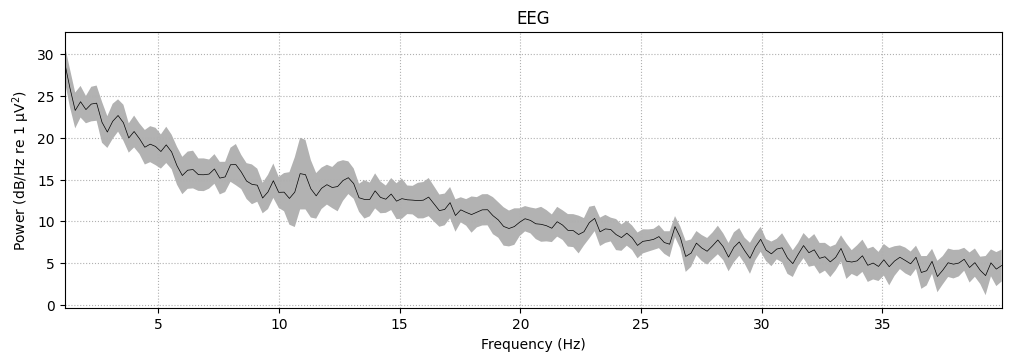

In [10]:
# Visualize average PSD
fig = psd.plot(average=True)
plt.show()

Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


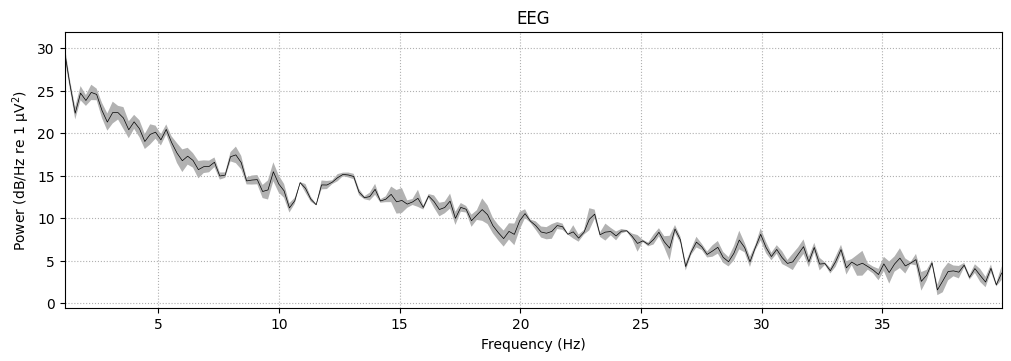

In [11]:
# Visualize PSD over Motor Cortex only

motor_channels = ["C3","Cz","C4"]

fig = psd.plot(
    picks=motor_channels,
    average=True
)

plt.show()

In [12]:
# Extract PSD values
psd_data = psd.get_data()

print("PSD Matrix Shape is:")
print(psd_data.shape)

PSD Matrix Shape is:
(15, 64, 176)
